# Annotation analysis

Exploratory statistics on the moment-retrieval annotations, focused on the
quantities that matter for training the query-conditioned GT visual-token
reconstructor:

- how many annotations / unique videos there are (and annotations per video),
- the **ground-truth moment duration** distribution,
- **degenerate / near-empty GT windows**,
- where the moment sits inside the video,
- question length and `primaryLabel` distribution.

The analysis is run twice: once over **all** annotations, once over the
**EGO4D** subset only.

In [2]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- configuration -------------------------------------------------------
# Point this at the annotations JSON. Defaults to the local data path; on the
# cluster set it to e.g. /home/<user>/rosario/annotations.json.
ANNOTATIONS_PATH = Path("../data/annotations.json")

# Training assumptions, used to flag how many GT windows the model cannot fully
# emit. Tokens are pooled to ~POOL_FPS frames/second, so a moment of D seconds
# yields roughly D * POOL_FPS target tokens.
POOL_FPS = 1
OUT_LEN = 32         # fixed-decode output length
MAX_OUT_LEN = 64     # length-aware decode cap
MIN_VALID_DURATION = 1.0  # windows shorter than this trigger the Empty-GT fallback

pd.set_option("display.float_format", lambda v: f"{v:.3f}")

In [3]:
def load_annotations(path: Path) -> list:
    """Load the raw annotation list (unwraps a dict wrapper if present)."""
    with open(path, "r", encoding="utf-8") as f:
        obj = json.load(f)
    if isinstance(obj, dict):
        for key in ("annotations", "data", "samples"):
            if key in obj and isinstance(obj[key], list):
                obj = obj[key]
                break
    if not isinstance(obj, list):
        raise ValueError("Annotations must be a JSON list.")
    return obj


def _moment_span(item: dict):
    """Return (start_second, end_second) of the M1 moment, or (nan, nan)."""
    try:
        span = item["absolute_moments"]["M1"]["Moment_timespan"]
        return float(span["start_second"]), float(span["end_second"])
    except Exception:
        return math.nan, math.nan


def _norm_id(value):
    """Coerce an id to a hashable scalar. Some records store video_id as a dict
    (e.g. {"id": ...}); pull a likely key, else fall back to a stable string so
    groupby/nunique don't choke on unhashable dicts."""
    if isinstance(value, dict):
        for key in ("id", "video_id", "uid", "name"):
            if key in value:
                return str(value[key])
        return json.dumps(value, sort_keys=True)
    if isinstance(value, list):
        return json.dumps(value, sort_keys=True)
    return value


def to_dataframe(items: list) -> pd.DataFrame:
    """Flatten raw annotations into a tidy DataFrame with training-relevant cols."""
    rows = []
    for it in items:
        if not isinstance(it, dict):
            continue
        gs, ge = _moment_span(it)
        q = it.get("question")
        qt = it.get("absolute_query_time")
        rows.append(
            {
                "video_id": _norm_id(it.get("video_id")),
                "dataset": str(it.get("dataset", "")).strip().lower(),
                "question": q,
                "primary_label": it.get("primaryLabel", "?"),
                "annotation_id": it.get("annotation_id"),
                "gt_start": gs,
                "gt_end": ge,
                "query_time": float(qt) if qt is not None else math.nan,
            }
        )
    df = pd.DataFrame(rows)

    # derived columns
    df["gt_duration"] = df["gt_end"] - df["gt_start"]
    df["approx_target_tokens"] = df["gt_duration"] * POOL_FPS
    df["question_words"] = df["question"].fillna("").str.split().apply(len)
    # fraction of the way through the (queryable) video the moment starts
    df["gt_start_frac"] = np.where(
        df["query_time"] > 0, df["gt_start"] / df["query_time"], np.nan
    )

    # validity flags (mirror read_annotations + flag degenerate windows)
    df["has_video"] = df["video_id"].notna() & (df["video_id"].astype(str) != "")
    df["has_question"] = df["question"].notna() & (df["question"].astype(str) != "")
    df["finite_span"] = np.isfinite(df["gt_start"]) & np.isfinite(df["gt_end"])
    df["valid"] = df["has_video"] & df["has_question"] & df["finite_span"]
    df["degenerate"] = df["finite_span"] & (df["gt_duration"] < MIN_VALID_DURATION)
    return df


raw = load_annotations(ANNOTATIONS_PATH)
df_all = to_dataframe(raw)
print(f"Loaded {len(raw)} raw records -> {len(df_all)} parsed rows")
df_all.head()

Loaded 2250 raw records -> 2250 parsed rows


,video_id,dataset,question,primary_label,annotation_id,gt_start,gt_end,query_time,gt_duration,approx_target_tokens,question_words,gt_start_frac,has_video,has_question,finite_span,valid,degenerate
0,5ccb96c6-714f-4a93-9352-540899b27a4d,ego4d,Where did I put a pair of scissors?,SPAT,1,705.700,721.000,1199.967,15.300,15.300,8,0.588,True,True,True,True,False
1,5ccb96c6-714f-4a93-9352-540899b27a4d,ego4d,Where is my dreamers yora?,SPAT,2,1014.828,1023.000,1199.967,8.172,8.172,5,0.846,True,True,True,True,False
2,cab983c1-d36e-4afa-8116-1e2bde4a4a4c,ego4d,Where is my cup?,SPAT,3,105.442,108.354,480.033,2.911,2.911,4,0.220,True,True,True,True,False
3,93ca6e76-2409-41f7-be7c-28f457f04f57,ego4d,What did I pour in the dish?,DETL,4,310.074,338.000,441.967,27.926,27.926,7,0.702,True,True,True,True,False
4,93ca6e76-2409-41f7-be7c-28f457f04f57,ego4d,what did I put in a microwave?,DETL,5,287.294,287.294,441.967,0.000,0.000,7,0.650,True,True,True,True,True


## Reusable summary

`summarize(df, name)` prints the headline counts and draws the distributions
that matter for training. It is called once for all annotations and once for
the EGO4D subset.

In [4]:
def summarize(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Print headline stats + plot training-relevant distributions. Returns the
    duration describe() table for convenience."""
    print("=" * 70)
    print(f"SUMMARY: {name}")
    print("=" * 70)

    n = len(df)
    n_valid = int(df["valid"].sum())
    n_videos = df.loc[df["valid"], "video_id"].nunique()
    print(f"records                : {n}")
    print(f"valid (trainable)      : {n_valid}  ({100*n_valid/max(1,n):.1f}%)")
    print(f"unique videos (valid)  : {n_videos}")
    print(f"  dropped: no video={int((~df['has_video']).sum())} "
          f"no question={int((~df['has_question']).sum())} "
          f"bad span={int((~df['finite_span']).sum())}")

    valid = df[df["valid"]].copy()
    if valid.empty:
        print("No valid rows — nothing to plot.")
        return pd.DataFrame()

    # annotations per video
    per_video = valid.groupby("video_id").size()
    print("\nannotations per video  : "
          f"mean={per_video.mean():.2f} median={per_video.median():.0f} "
          f"min={per_video.min()} max={per_video.max()}")

    # GT duration
    dur = valid["gt_duration"]
    print("\nGT duration (s)        : "
          f"mean={dur.mean():.2f} median={dur.median():.2f} "
          f"min={dur.min():.2f} max={dur.max():.2f}")
    for p in (50, 90, 95, 99):
        print(f"  p{p:<2} = {np.percentile(dur, p):.2f} s")

    # degenerate + truncation relative to training caps
    n_deg = int(valid["degenerate"].sum())
    n_gt_out = int((valid["approx_target_tokens"] > OUT_LEN).sum())
    n_gt_max = int((valid["approx_target_tokens"] > MAX_OUT_LEN).sum())
    print(f"\ndegenerate (<{MIN_VALID_DURATION}s)     : {n_deg}  "
          f"({100*n_deg/len(valid):.1f}%)  -> trigger Empty-GT fallback")
    print(f"duration > OUT_LEN={OUT_LEN}    : {n_gt_out}  "
          f"({100*n_gt_out/len(valid):.1f}%)  -> truncated in fixed decode")
    print(f"duration > MAX_OUT_LEN={MAX_OUT_LEN} : {n_gt_max}  "
          f"({100*n_gt_max/len(valid):.1f}%)  -> truncated in length-aware decode")

    # question length
    qw = valid["question_words"]
    print(f"\nquestion length (words): mean={qw.mean():.1f} "
          f"median={qw.median():.0f} max={qw.max()}")

    # primary label distribution
    print("\nprimaryLabel distribution:")
    print(valid["primary_label"].value_counts().to_string())

    # --- plots -----------------------------------------------------------
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.suptitle(f"Annotation statistics — {name}", fontsize=14)

    # 1) GT duration (clip the long tail for readability)
    clip = np.percentile(dur, 99)
    axes[0, 0].hist(dur.clip(upper=clip), bins=40, color="#1f77b4", edgecolor="white")
    
    axes[0, 0].set_title("GT duration (s, clipped at p99)")
    axes[0, 0].set_xlabel("seconds"); axes[0, 0].set_ylabel("count"); axes[0, 0].legend()

    # 2) annotations per video
    axes[0, 1].hist(per_video.values, bins=range(1, int(per_video.max()) + 2),
                    color="#4CAF50", edgecolor="white", align="left")
    axes[0, 1].set_title("Annotations per video")
    axes[0, 1].set_xlabel("annotations"); axes[0, 1].set_ylabel("videos")

    # 3) question length
    axes[0, 2].hist(qw.values, bins=30, color="#9C27B0", edgecolor="white")
    axes[0, 2].set_title("Question length (words)")
    axes[0, 2].set_xlabel("words"); axes[0, 2].set_ylabel("count")

    # 4) GT start position (absolute)
    axes[1, 0].hist(valid["gt_start"].clip(upper=np.percentile(valid['gt_start'], 99)),
                    bins=40, color="#FF9800", edgecolor="white")
    axes[1, 0].set_title("GT start time (s, clipped at p99)")
    axes[1, 0].set_xlabel("seconds"); axes[1, 0].set_ylabel("count")

    # 5) GT start as fraction of query_time (where in the video)
    frac = valid["gt_start_frac"].dropna()
    frac = frac[(frac >= 0) & (frac <= 1)]
    axes[1, 1].hist(frac.values, bins=20, color="#F44336", edgecolor="white")
    axes[1, 1].set_title("GT start / query_time (position in video)")
    axes[1, 1].set_xlabel("fraction [0=start, 1=query time]"); axes[1, 1].set_ylabel("count")

    # 6) primaryLabel bars
    vc = valid["primary_label"].value_counts()
    axes[1, 2].bar(vc.index.astype(str), vc.values, color="#2196F3")
    axes[1, 2].set_title("primaryLabel distribution")
    axes[1, 2].set_xlabel("label"); axes[1, 2].set_ylabel("count")
    axes[1, 2].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()
    return dur.describe().to_frame("gt_duration")

## 1. All annotations

dataset composition (valid rows):
dataset
multihop-egoqa    578
ego4d             498
egolife           432
egotempo          425
hd-epic           316

SUMMARY: ALL annotations
records                : 2250
valid (trainable)      : 2249  (100.0%)
unique videos (valid)  : 1460
  dropped: no video=0 no question=0 bad span=1

annotations per video  : mean=1.54 median=1 min=1 max=14

GT duration (s)        : mean=14.46 median=3.00 min=0.00 max=473.19
  p50 = 3.00 s
  p90 = 47.00 s
  p95 = 64.58 s
  p99 = 116.98 s

degenerate (<1.0s)     : 597  (26.5%)  -> trigger Empty-GT fallback
duration > OUT_LEN=32    : 342  (15.2%)  -> truncated in fixed decode
duration > MAX_OUT_LEN=64 : 123  (5.5%)  -> truncated in length-aware decode

question length (words): mean=10.0 median=9 max=32

primaryLabel distribution:
primary_label
DETL    614
EVNT    480
SPAT    360
TEMP    320
SOC     230
CAUS    159
PROS     86


/var/folders/zl/kd9vcnbj57s5smzwc29gsqdr0000gn/T/ipykernel_6723/2692185989.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].set_xlabel("seconds"); axes[0, 0].set_ylabel("count"); axes[0, 0].legend()


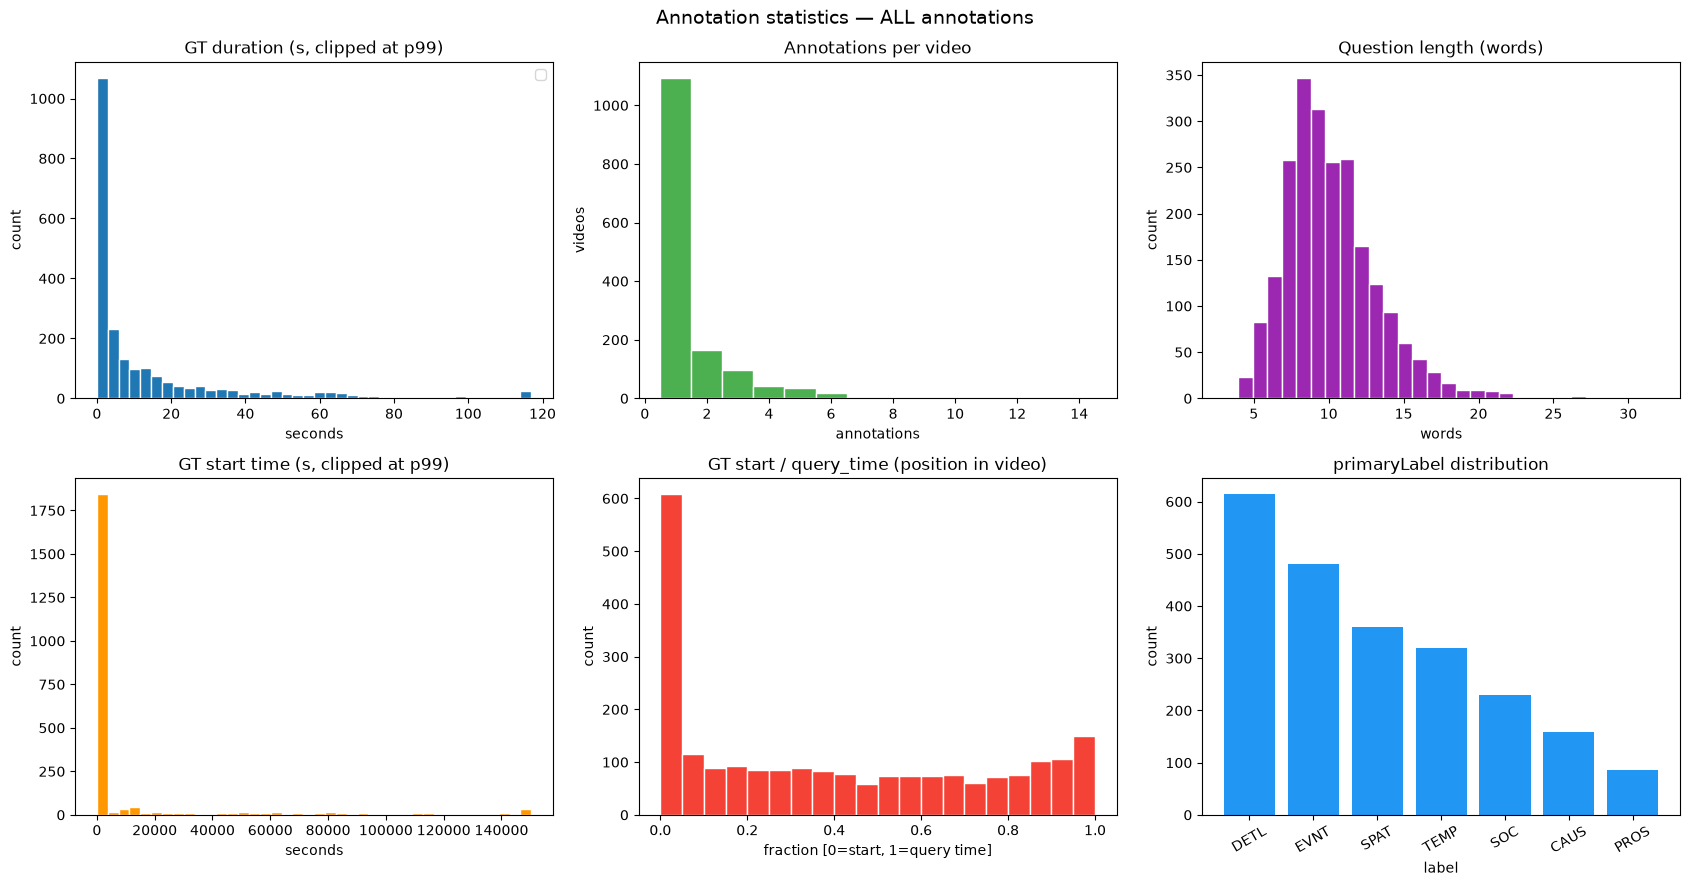

,gt_duration
count,2249.000
mean,14.456
std,25.415
min,0.000
25%,0.800
50%,3.000
75%,16.551
max,473.188


In [5]:
# dataset composition (only meaningful across all annotations)
print("dataset composition (valid rows):")
print(df_all.loc[df_all["valid"], "dataset"].value_counts().to_string())
print()
summarize(df_all, "ALL annotations")

## 2. EGO4D only

SUMMARY: EGO4D only
records                : 498
valid (trainable)      : 498  (100.0%)
unique videos (valid)  : 148
  dropped: no video=0 no question=0 bad span=0

annotations per video  : mean=3.36 median=3 min=1 max=14

GT duration (s)        : mean=12.28 median=4.51 min=0.00 max=473.19
  p50 = 4.51 s
  p90 = 29.70 s
  p95 = 47.52 s
  p99 = 102.00 s

degenerate (<1.0s)     : 71  (14.3%)  -> trigger Empty-GT fallback
duration > OUT_LEN=32    : 48  (9.6%)  -> truncated in fixed decode
duration > MAX_OUT_LEN=64 : 16  (3.2%)  -> truncated in length-aware decode

question length (words): mean=7.6 median=8 max=17

primaryLabel distribution:
primary_label
DETL    265
SPAT    178
EVNT     30
SOC      18
TEMP      7


/var/folders/zl/kd9vcnbj57s5smzwc29gsqdr0000gn/T/ipykernel_6723/2692185989.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].set_xlabel("seconds"); axes[0, 0].set_ylabel("count"); axes[0, 0].legend()


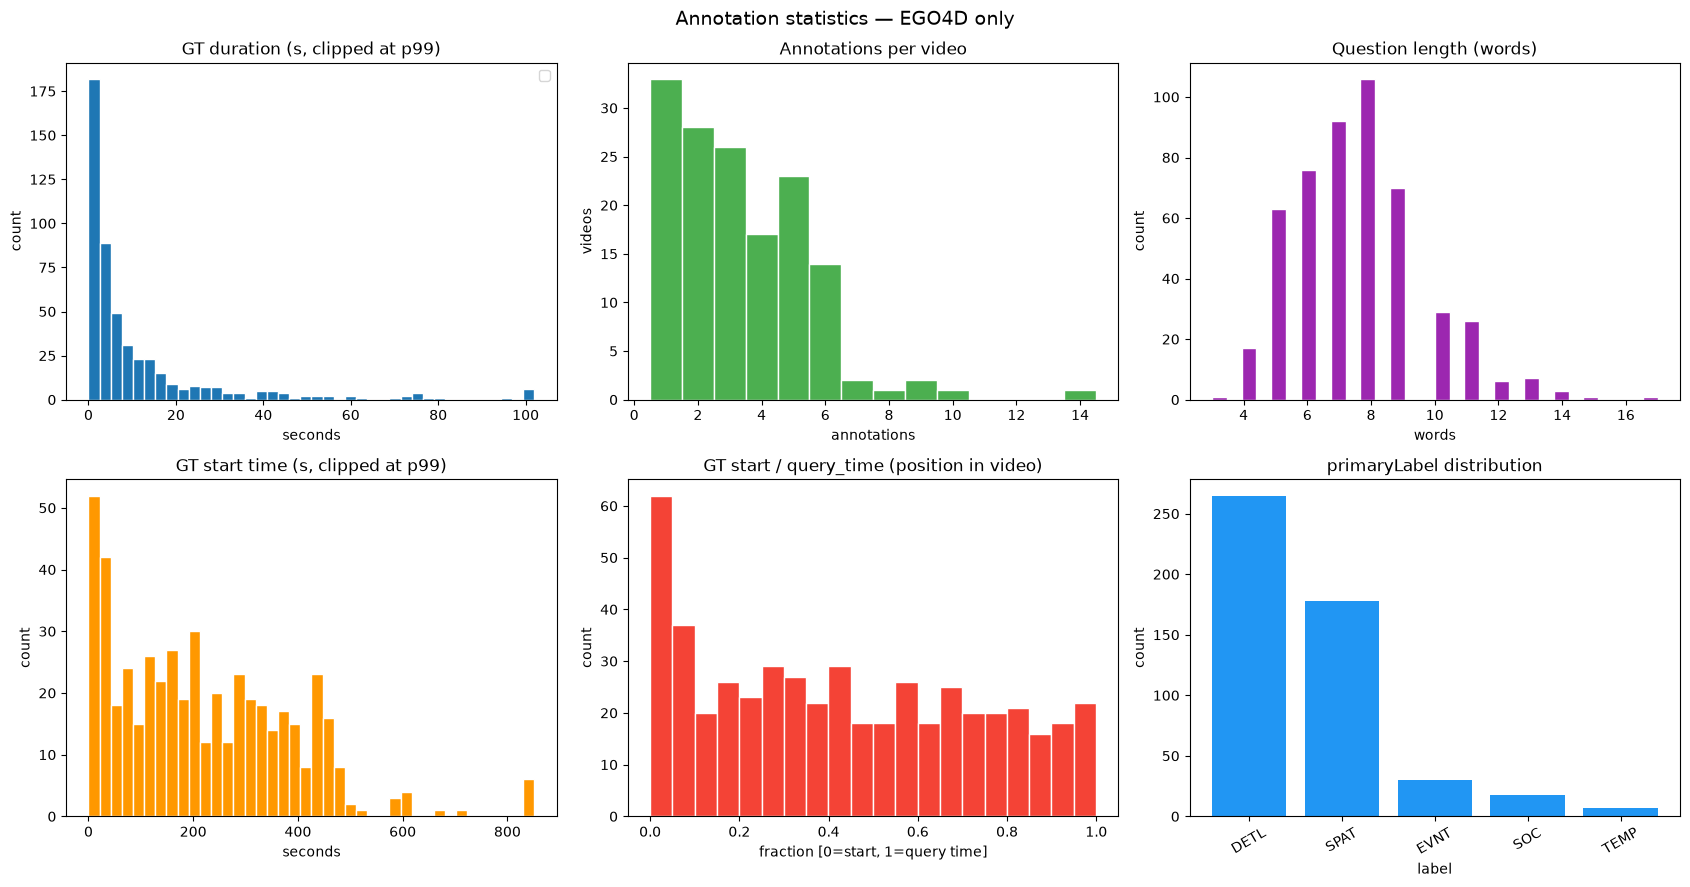

,gt_duration
count,498.000
mean,12.281
std,27.976
min,0.000
25%,1.549
50%,4.509
75%,12.363
max,473.188


In [6]:
df_ego = df_all[df_all["dataset"] == "ego4d"].copy()
summarize(df_ego, "EGO4D only")

In [7]:
# Example questions per primaryLabel — so the meaning of the abbreviations
# (DETL, SPAT, EVNT, SOC, TEMP, ...) is clear from the data, not guessed.
# The [Xs] prefix is the GT moment duration.
def show_examples(df: pd.DataFrame, n: int = 5, seed: int = 0) -> None:
    """Print up to ``n`` example questions per primaryLabel (most frequent first)."""
    labels = df["primary_label"].value_counts().index
    for lbl in labels:
        sub = df[df["primary_label"] == lbl]
        k = min(n, len(sub))
        sample = sub.sample(k, random_state=seed) if len(sub) > k else sub
        print(f"\n=== {lbl}  ({len(sub)} annotations) ===")
        for _, r in sample.iterrows():
            print(f"  [{r['gt_duration']:5.1f}s]  {r['question']}")


show_examples(df_ego, n=5)


=== DETL  (265 annotations) ===
  [  1.9s]  What tool did I pick?
  [  0.0s]  What color was the hammer on the floor?
  [ 10.8s]  What did I pour on the meat?
  [  9.1s]  How many pastries did I put on the tray?
  [  4.2s]  What color is the cooker?

=== SPAT  (178 annotations) ===
  [  4.8s]  In what place did I see the black sock?
  [  1.0s]  Where was the broth before I picked it?
  [  5.3s]  In what location did I see a hammer?
  [  0.0s]  what did  I put in the cutlery rack?
  [ 75.6s]  where did  put the clothe before I hanged them?

=== EVNT  (30 annotations) ===
  [ 70.0s]  What tool did I use to loosen the bolt?
  [  1.7s]  Did I leave the cooker turned on?
  [ 17.0s]  Did I leave the tap water running?
  [  2.3s]  Did I unplug a plug from a socket on the wall?
  [ 15.2s]  Did I leave the container open?

=== SOC  (18 annotations) ===
  [  5.0s]  Who did I talk to in the workshop?
  [  0.6s]  Who was with me when I picked up the tent bag by the edge?
  [ 44.0s]  Who was with 